### Importing Libraries

In [1]:
import matplotlib.pyplot as plt
from pathlib import Path
from RigolWFM import Wfm
from datetime import datetime
import numpy as np
import pandas as pd

### Helper Functions

In [2]:
def parse_timestamp(path: Path) -> datetime:
    # Extracts '20260928013724716' → datetime
    parts = path.stem.split("_")
    ts_str = parts[-1][:17]  # first 17 digits: YYYYMMDDHHMMSSmmm

    return datetime.strptime(ts_str, "%Y%m%d%H%M%S%f")

def bfield_at(wfm_files, start_bfield, ramp_rate) -> float:
    start_time = parse_timestamp(wfm_files[0])
    elapsed = np.array([(parse_timestamp(f) - start_time).total_seconds()for f in wfm_files])
    
    return start_bfield + (ramp_rate * elapsed)

def parse_waveforms(wfm_files, output_csv, start_bfield, ramp_rate):
    b_fields = bfield_at(wfm_files, start_bfield, ramp_rate)
    
    rows = []
    for f, b in zip(wfm_files, b_fields):
        try:
            w = Wfm.from_file(str(f))
            for ch in w.channels:
                if ch is not None and ch.enabled:
                    times = ch.times
                    volts = ch.volts 
                    
                    peak_amp = volts.min()
                    peak_idx = volts.argmin()
                    peak_time = times[peak_idx]
                    
                    # Pulse width: time between threshold crossings
                    threshold = peak_amp * 0.5
                    crossed = np.where(volts < threshold)[0]
                    pulse_width = times[crossed[-1]] - times[crossed[0]] if len(crossed) > 1 else np.nan
                    
                    # Integrated area (flux)
                    integrated_flux = np.trapezoid(volts, times)

                    sum_peak = np.sum(volts)
                    
                    rows.append({
                        "filename":       f.name,
                        "trigtime":       parse_timestamp(f).isoformat().split("T")[1],
                        "b_field":        b,
                        "peak_amp":       peak_amp,
                        "peak_time":      peak_time,
                        "pulse_width":    pulse_width,
                        "integrated_flux": integrated_flux,
                        "sum_peak": sum_peak
                    })
        except Exception as e:
            print(f"Skipped {f.name}: {e}")

    df = pd.DataFrame(rows)
    df.to_csv(output_csv, index=False)
    print(f"Saved {len(df)} rows → {output_csv}")

    return df

def plot_waveforms(dir, wfm_files):
    fig, ax = plt.subplots(figsize=(14, 6))

    for file_path in wfm_files:
        try:
            w = Wfm.from_file(str(file_path))
            for ch in w.channels:
                if ch is not None and ch.enabled:
                    ax.plot(ch.times, ch.volts, linewidth=0.8)
            # print(f"  ✓ Loaded: {file_path.name}")
        except Exception as e:
            print(f"  ✗ Skipped {file_path.name}: {e}")

    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Voltage (V)")
    ax.set_title(f"All Waveforms in {dir}")
    # ax.legend(fontsize=6, loc="upper right")
    ax.grid(True)
    plt.tight_layout()
    # plt.savefig(directory / "all_waveforms.png", dpi=150)
    plt.show()

def plott(df, x_axis, y_axis, temperature, dir):
    fig, ax = plt.subplots(figsize=(8, 5))

    ax.scatter(df[x_axis], df[y_axis], s=10, alpha=0.7, color="steelblue")

    ax.set_xlabel(x_axis)
    ax.set_ylabel(y_axis)
    ax.set_title(f"{y_axis} vs {x_axis} at {temperature} K")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    # plt.savefig(dir / f"flux_vs_bfield_T{temperature}K.png", dpi=700)
    # plt.show()


### Parsing Data

In [3]:
dir = Path("/mnt/t2/magnet4/")
temperature = 7.5
ramp_rate = -0.005 #T/sec
start_bfield = 2 #T

wfm_files = sorted(dir.glob("*.wfm"))
print(f"Found {len(wfm_files)} waveform files")
parsed_data = parse_waveforms(wfm_files, "parsed_magnet4.csv", start_bfield, ramp_rate)

Found 3546 waveform files
Saved 3546 rows → parsed_magnet4.csv


In [ ]:
plot_waveforms(dir, wfm_files)

### Some Plots

In [ ]:
plott(parsed_data, "b_field", "peak_amp", temperature,dir)
plt.xlim(0,2)
plt.show()

Selected 40 waveforms


/tmp/ipykernel_605589/2464354373.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


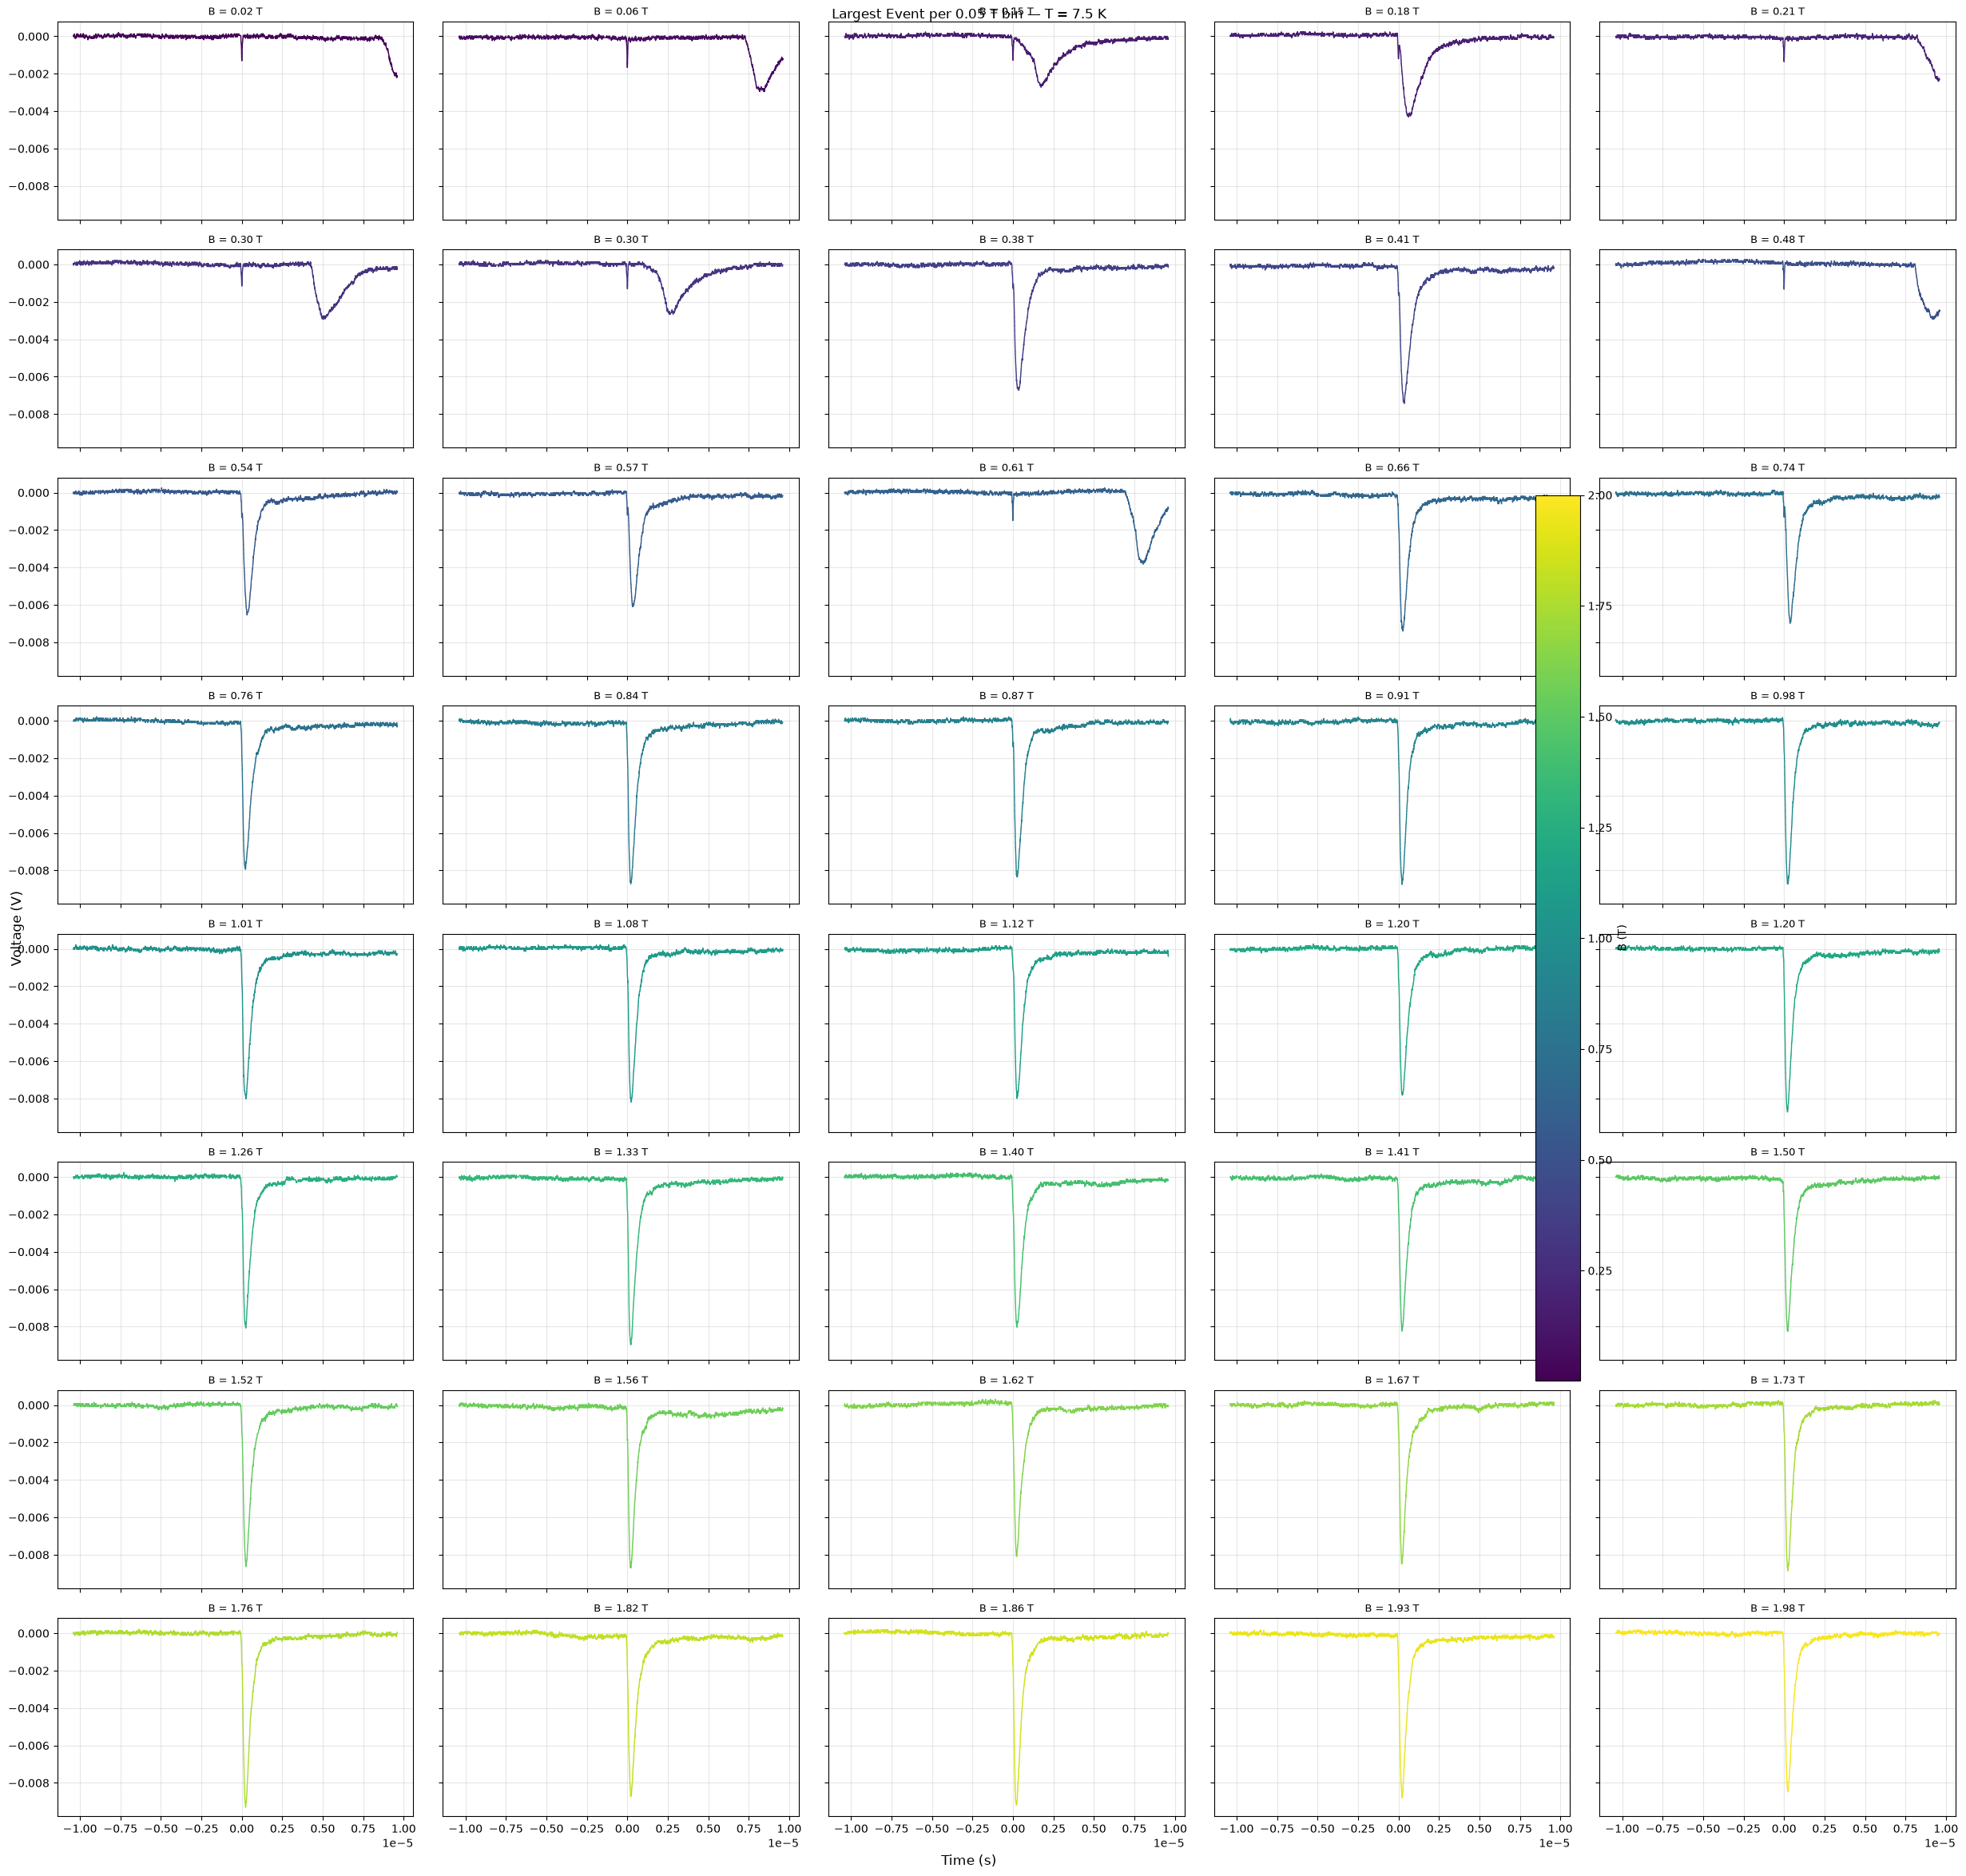

In [7]:
def plot_sampled_waveforms(df, wfm_dir, bin_size=0.5, temperature=7.5,
                           b_min=None, b_max=None):
    
    df = df.copy()
    if b_min is not None:
        df = df[df["b_field"] >= b_min]
    if b_max is not None:
        df = df[df["b_field"] <= b_max]

    df["bin"] = ((df["b_field"] - df["b_field"].min()) / bin_size).astype(int)
    selected = df.loc[df.groupby("bin")["peak_amp"].idxmin()].sort_values("b_field")
    n = len(selected)
    print(f"Selected {n} waveforms")

    ncols = 5
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3 * nrows), sharex=True, sharey=True)
    axes = axes.flatten()

    cmap = plt.cm.viridis
    norm = plt.Normalize(df["b_field"].min(), df["b_field"].max())

    for i, (_, row) in enumerate(selected.iterrows()):
        ax = axes[i]
        try:
            f = wfm_dir / row["filename"]
            w = Wfm.from_file(str(f))
            for ch in w.channels:
                if ch is not None and ch.enabled:
                    times = ch.times
                    volts = ch.volts - ch.volts[:100].mean()
                    ax.plot(times, volts, color=cmap(norm(row["b_field"])), lw=1.0)
        except Exception as e:
            ax.text(0.5, 0.5, f"Error", transform=ax.transAxes, ha="center")

        ax.set_title(f"B = {row['b_field']:.2f} T", fontsize=9)
        ax.grid(True, alpha=0.3)

    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    # Shared axis labels
    fig.supxlabel("Time (s)")
    fig.supylabel("Voltage (V)")
    fig.suptitle(f"Largest Event per {bin_size} T bin — T = {temperature} K", fontsize=12)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    fig.colorbar(sm, ax=axes, label="B (T)", shrink=0.6)

    plt.tight_layout()
    # plt.savefig(wfm_dir / f"sampled_subplots_T{temperature}K_{b_min}to{b_max}T.png", dpi=150)
    plt.show()

# Usage
plot_sampled_waveforms(parsed_data, wfm_dir=dir, bin_size=0.05, temperature=temperature,
                       b_min=0, b_max=2)